In [1]:
import warnings
warnings.filterwarnings('ignore')

# Importing the Required Modules

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report,roc_curve

# Loading the dataset in the form of the DataFrame

In [3]:
df=pd.read_csv('/kaggle/input/breast-cancer-dataset/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Extracting useful info from the dataset

In [4]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# Prior treatment before classification

In [7]:
df=df.drop(columns=['Unnamed: 32','id'])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Cheecking for NaN values

In [8]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

# Allah's Mercy. No NULL values :)

In [9]:
df=pd.get_dummies(df,drop_first=True,columns=['diagnosis'],dtype=int)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [10]:
columns=df.columns

# Looking for outliers very much

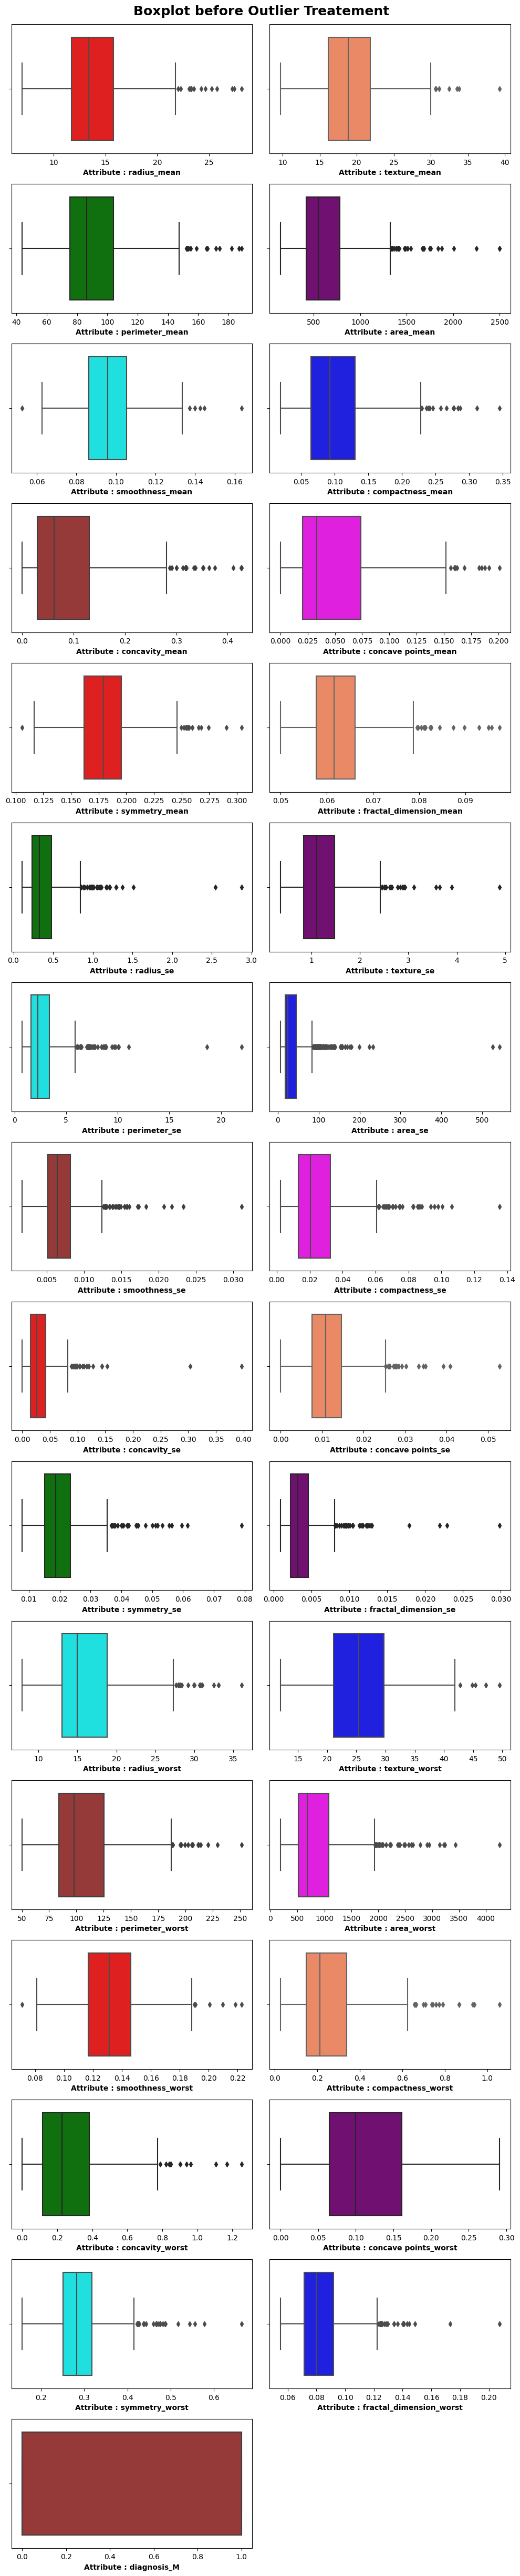

In [11]:
fig,axes=plt.subplots(16,2,figsize=(10,50))
axes=axes.flatten()
fig.delaxes(axes[-1])
colour=['red','coral','green','purple','cyan','blue','brown','magenta']*4

for index in range(len(columns)):
    sns.boxplot(x=df[columns[index]],color=colour[index],ax=axes[index])
    axes[index].set_xlabel(f"Attribute : {columns[index]}", fontweight='bold')
plt.suptitle("Boxplot before Outlier Treatement\n\n\n", fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

# Outlier treatement function

In [12]:
def outlier_removal(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1

    lower_bound,upper_bound=Q1-1.5*IQR,Q3+1.5*IQR
    df[column]=df[column].clip(lower=lower_bound,upper=upper_bound)

In [13]:
for column in columns:
    outlier_removal(column)

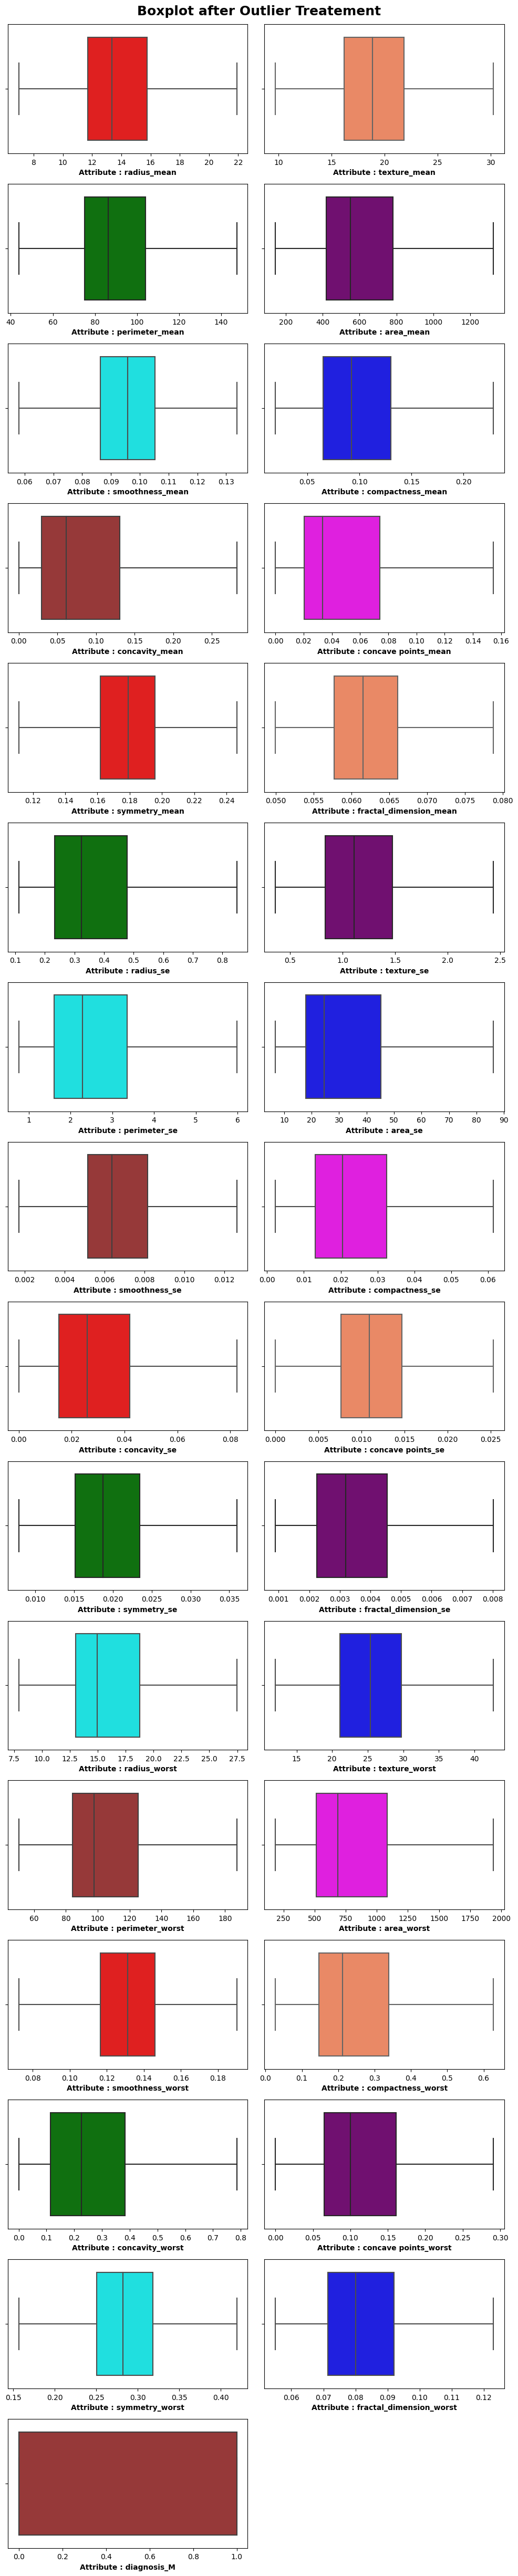

In [14]:
fig,axes=plt.subplots(16,2,figsize=(10,50))
axes=axes.flatten()
fig.delaxes(axes[-1])
colour=['red','coral','green','purple','cyan','blue','brown','magenta']*4

for index in range(len(columns)):
    sns.boxplot(x=df[columns[index]],color=colour[index],ax=axes[index])
    axes[index].set_xlabel(f"Attribute : {columns[index]}", fontweight='bold')
plt.suptitle("Boxplot after Outlier Treatement\n\n\n", fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

# Outlier Removal Achieved

In [15]:
target=df['diagnosis_M']
df=df.drop(columns=['diagnosis_M'])
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758
3,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,0.07875,...,14.91,26.50,98.87,567.70,0.1901,0.62695,0.6869,0.2575,0.41915,0.12301
4,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.00,0.1374,0.20500,0.4000,0.1625,0.23640,0.07678


# Scaling the data

In [16]:
scaler=StandardScaler()
df=pd.DataFrame(scaler.fit_transform(df),columns=df.columns)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.176800,-2.121200,1.357375,1.184085,1.618861,2.541404,2.647422,2.620973,2.348535,2.511708,...,2.006477,-1.375159,2.439568,2.287627,1.344848,2.641905,2.246192,2.296076,2.443918,2.225247
1,1.949929,-0.354875,1.795991,2.249396,-0.842995,-0.498189,-0.000497,0.574944,0.017882,-0.925449,...,1.921384,-0.370048,1.631542,2.287627,-0.377098,-0.443388,-0.137634,1.087084,-0.234408,0.355314
2,1.686226,0.476899,1.670052,1.846217,0.975239,1.148680,1.496076,2.110330,1.004666,-0.407692,...,1.611558,-0.019582,1.434234,1.807751,0.546654,1.223448,0.920718,1.955000,1.369057,0.265197
3,-0.791983,0.268955,-0.606410,-0.831485,2.737521,2.541404,2.091997,1.506601,2.521318,2.517947,...,-0.277945,0.140773,-0.245395,-0.593838,2.595949,2.641905,2.119474,2.175786,2.443918,2.482456
4,1.866023,-1.174698,1.891531,2.154338,0.295047,0.599453,1.504202,1.482665,0.006363,-0.588595,...,1.386825,-1.484267,1.424838,1.525780,0.232758,-0.314469,0.665254,0.729259,-0.951602,-0.410683


In [17]:
x_train,x_test,y_train,y_test=train_test_split(df,target,random_state=42,test_size=0.2,stratify=target)

# Checking stratify working

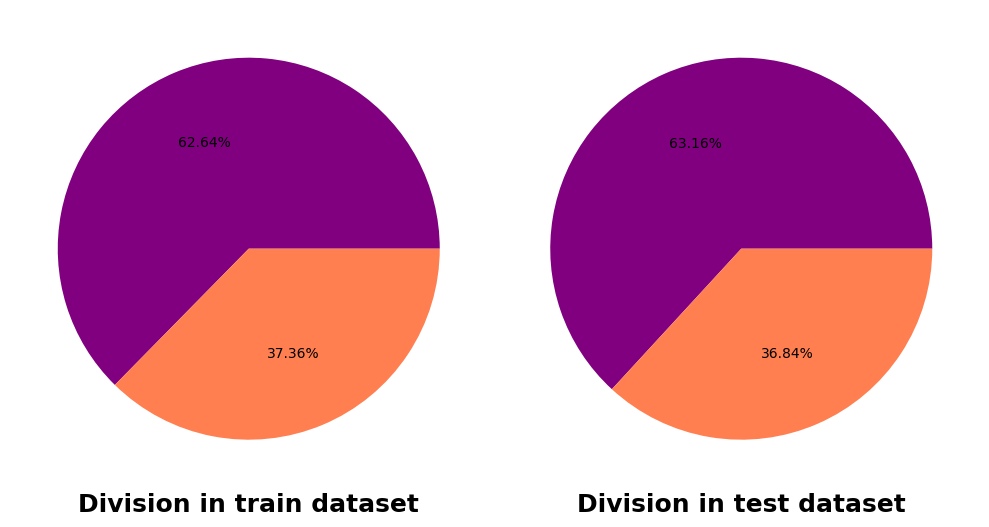

In [18]:
fig,axes=plt.subplots(1,2,figsize=(10,6))

axes[0].pie(y_train.value_counts(),colors=['purple','coral'],autopct='%1.2f%%')
axes[0].set_xlabel("Division in train dataset",fontweight='bold', fontsize=18)

axes[1].pie(y_test.value_counts(),colors=['purple','coral'],autopct='%1.2f%%')
axes[1].set_xlabel("Division in test dataset",fontweight='bold', fontsize=18)

plt.tight_layout()
plt.show()

# The efficiency is very close to 1. Nice :)

# Building the model and training it

In [19]:
model=KNeighborsClassifier(n_neighbors=2, weights='distance')
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=2, weights='distance')

# Predicting based on the model

In [20]:
prediction=model.predict(x_test)

# Comparison Table

In [21]:
dataframe_1=pd.DataFrame(y_test).reset_index().drop(columns=['index']).rename(columns={'diagnosis_M':'Actual_Values'})
dataframe_2=pd.DataFrame(prediction)
dataframe_2.columns=['Predicted_Values']

In [22]:
comparison=pd.concat((dataframe_1,dataframe_2),axis=1)
comparison.head()

,Actual_Values,Predicted_Values
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0


# Evaluating the model

In [23]:
print(f"Evaluating the Model\n{'*'*20}")
print("Accuracy:", round(accuracy_score(y_test, prediction)*100,2))
print("Precision:", round(precision_score(y_test, prediction)*100,2))
print("Recall:", round(recall_score(y_test, prediction)*100,2))
print("F1 Score:", round(f1_score(y_test, prediction),2))

Evaluating the Model
********************
Accuracy: 93.86
Precision: 92.68
Recall: 90.48
F1 Score: 0.92


In [24]:
print(f"Some more metrics for Model Evaluation\n{'*'*40}")
print(f'The confusion matrix \n{confusion_matrix(y_test,prediction)}')
print(f'\nThe precision score is : {round(precision_score(y_test,prediction)*100,2)}%')
print(f'\nThe roc_auc_score is : {round(roc_auc_score(y_test,prediction)*100,2)}%')
print(f'\nThe Classification Report \n{classification_report(y_test,prediction)}')

Some more metrics for Model Evaluation
****************************************
The confusion matrix 
[[69  3]
 [ 4 38]]

The precision score is : 92.68%

The roc_auc_score is : 93.15%

The Classification Report 
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [25]:
cm = confusion_matrix(y_test, prediction)
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)
print("Specificity:", round(specificity * 100, 2))

probabilities = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, probabilities)
print("ROC-AUC Score:", round(auc * 100, 2))

Specificity: 95.83
ROC-AUC Score: 96.49


# Visualizing the model constructed

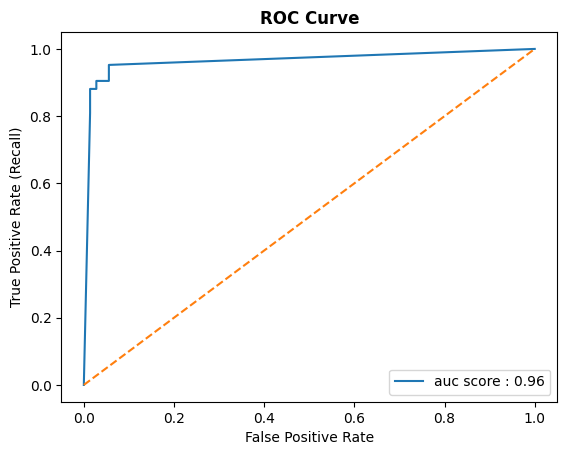

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.figure()
plt.plot(fpr, tpr, label=f'auc score : {round(auc,2)}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve",fontweight='bold')
plt.legend()
plt.show()

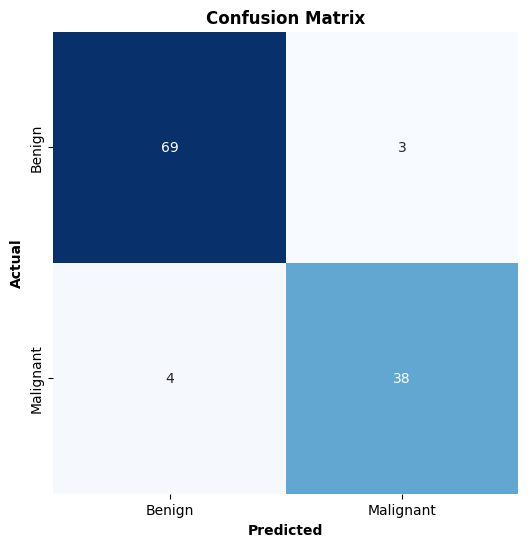

In [27]:
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)
plt.title("Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

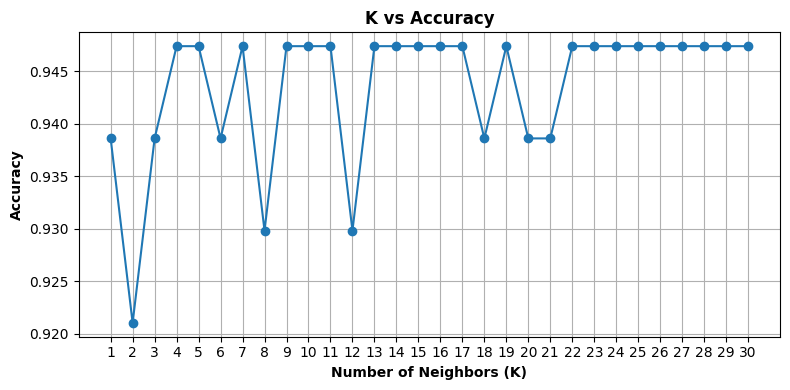

In [28]:
accuracy_scores = []

for k in range(1, 31):
    temp_model = KNeighborsClassifier(n_neighbors=k)
    temp_model.fit(x_train, y_train)
    pred = temp_model.predict(x_test)
    accuracy_scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,4))
plt.plot(range(1,31), accuracy_scores, marker='o')
plt.title("K vs Accuracy", fontweight='bold')
plt.xlabel("Number of Neighbors (K)", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')
plt.xticks(range(1,31))
plt.grid(True)
plt.tight_layout()
plt.show()

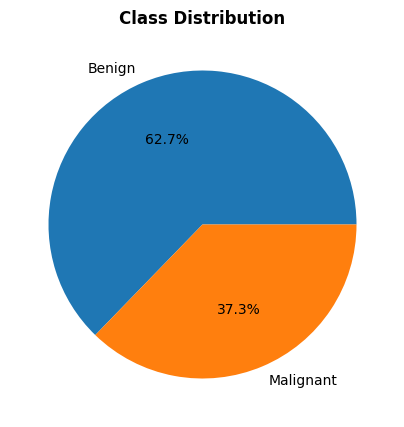

In [29]:
plt.figure(figsize=(5,5))
plt.pie(target.value_counts(), labels=['Benign','Malignant'], autopct='%1.1f%%')
plt.title("Class Distribution", fontweight='bold')
plt.show()

# Thanks :)